In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import NearestNeighbors
from pyclustertend import hopkins, vat
from sklearn.neighbors import NearestNeighbors
plt.style.use("default")

In [2]:
OUTPUT_DIR = "clusterability_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_parquet("scaled_emotion_dataset.parquet")
print(df.shape)
df.head()

emotion_columns = [
    "admiration", "amusement", "anger", "annoyance",
    "approval", "caring", "confusion", "curiosity",
    "desire", "disappointment", "disapproval", "disgust",
    "embarrassment", "excitement", "fear", "gratitude",
    "grief", "joy", "love", "nervousness",
    "optimism", "pride", "realization", "relief",
    "remorse", "sadness", "surprise", "neutral"
]

X = df[emotion_columns]
print(X.shape)

(61079, 30)
(61079, 28)


Hopkins Statistic

In [3]:
def hopkins_statistic(X, sample_size=1000, random_state=42):
    """
    Computes Hopkins Statistic.

    Parameters
    ----------
    X : pandas.DataFrame or numpy.ndarray
    sample_size : int
    random_state : int

    Returns
    -------
    Hopkins statistic
    """

    np.random.seed(random_state)

    if hasattr(X, "values"):
        X = X.values

    n, d = X.shape

    sample_size = min(sample_size, n // 2)

    # Fit nearest neighbour model
    nbrs = NearestNeighbors(n_neighbors=2)
    nbrs.fit(X)

    # -----------------------------
    # Random observations
    # -----------------------------
    mins = X.min(axis=0)
    maxs = X.max(axis=0)

    random_points = np.random.uniform(
        mins,
        maxs,
        size=(sample_size, d)
    )

    u_dist, _ = nbrs.kneighbors(random_points, n_neighbors=1)

    # -----------------------------
    # Real observations
    # -----------------------------
    indices = np.random.choice(n, sample_size, replace=False)

    real_points = X[indices]

    w_dist, _ = nbrs.kneighbors(real_points, n_neighbors=2)

    # second neighbour because first neighbour is itself
    w_dist = w_dist[:,1]

    H = u_dist.sum() / (u_dist.sum() + w_dist.sum())

    return H

In [4]:
print("=" * 80)
print("HOPKINS STATISTIC")
print("=" * 80)

X_np = X.to_numpy()
H = hopkins_statistic(X_np, 1000)

print(f"\nHopkins Statistic : {H:.4f}")

if H < 0.50:
    print("Interpretation : Random Data (Poor Clusterability)")

elif H < 0.70:
    print("Interpretation : Weak Cluster Tendency")

elif H < 0.85:
    print("Interpretation : Good Cluster Tendency")

else:
    print("Interpretation : Strong Cluster Tendency")

HOPKINS STATISTIC

Hopkins Statistic : 0.9759
Interpretation : Strong Cluster Tendency


In [5]:
print(X.shape)
print(type(X))

(61079, 28)
<class 'pandas.DataFrame'>


VAT Plot

<Figure size 800x800 with 0 Axes>

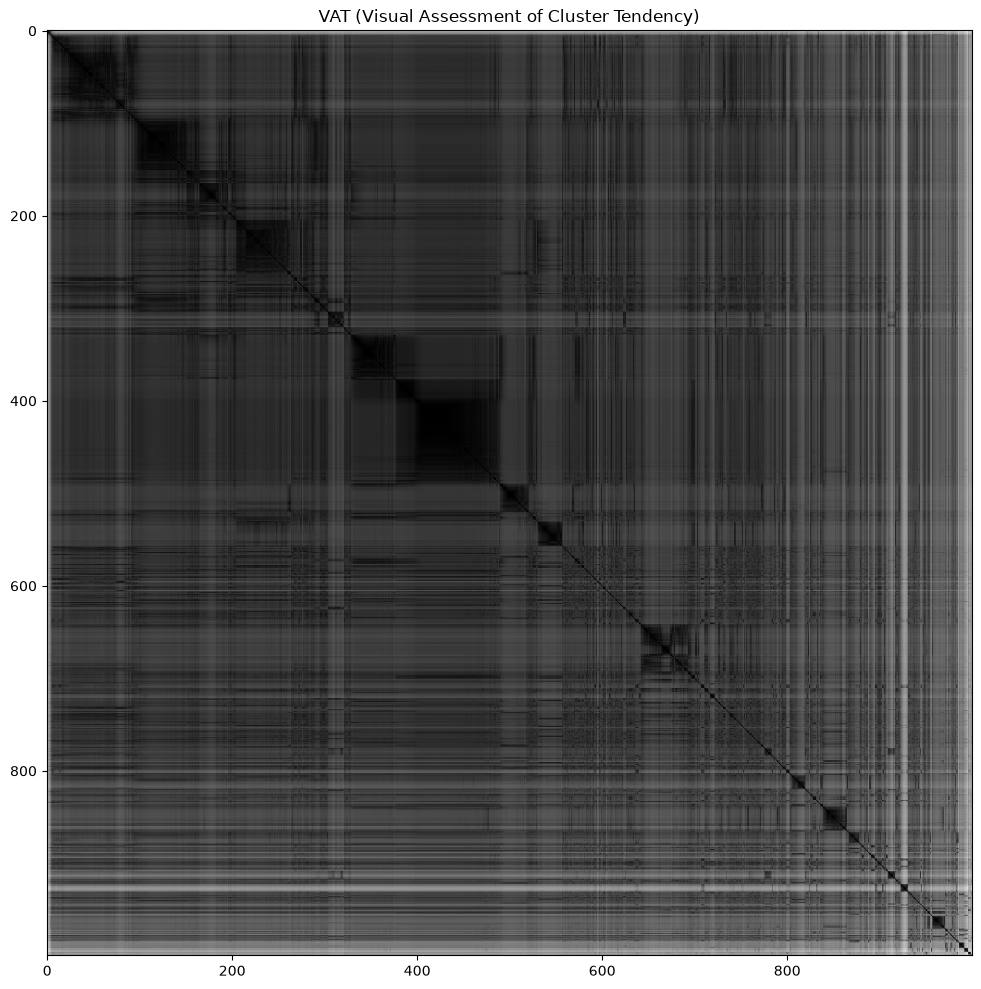

In [6]:
np.random.seed(42)

sample_size = 1000

X_sample = X.sample(
    n=sample_size,
    random_state=42
)

plt.figure(figsize=(8,8))

vat(X_sample.values)

plt.title("VAT (Visual Assessment of Cluster Tendency)")
plt.tight_layout()
plt.show()

Pairwise Distance Distribution

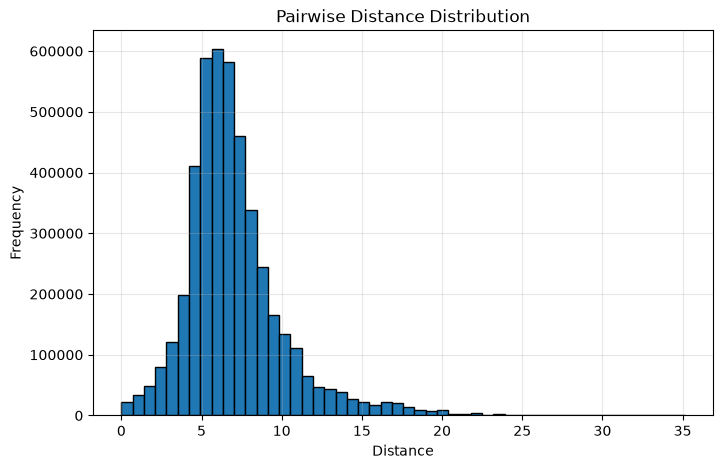

In [7]:
from scipy.spatial.distance import pdist

sample = X.sample(n=3000, random_state=42)

pairwise_distances = pdist(sample.values)

plt.figure(figsize=(8,5))

plt.hist(
    pairwise_distances,
    bins=50,
    edgecolor="black"
)

plt.title("Pairwise Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.savefig(
    os.path.join(OUTPUT_DIR, "pairwise_distance_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Nearest Neighbour Distance Distribution

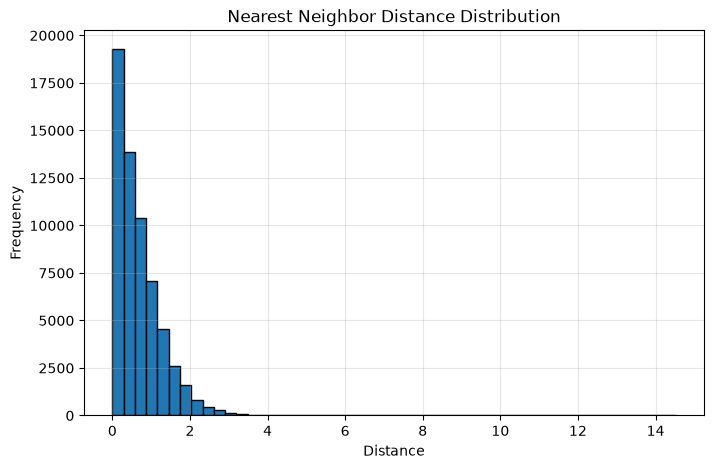

In [8]:
nn = NearestNeighbors(n_neighbors=2)

nn.fit(X)

distances, indices = nn.kneighbors(X)

nearest = distances[:,1]

plt.figure(figsize=(8,5))

plt.hist(
    nearest,
    bins=50,
    edgecolor="black"
)

plt.title("Nearest Neighbor Distance Distribution")

plt.xlabel("Distance")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.savefig(
    os.path.join(OUTPUT_DIR, "nearest_neighbor_distance.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Summary Report

In [9]:
print("=" * 80)
print("CLUSTERABILITY ANALYSIS SUMMARY")
print("=" * 80)

print(f"Dataset Shape      : {X.shape}")
print(f"Number of Features : {X.shape[1]}")
print(f"Number of Samples  : {X.shape[0]}")
print(f"Hopkins Statistic  : {H:.4f}")

if H < 0.50:
    interpretation = "Poor Clusterability"

elif H < 0.70:
    interpretation = "Weak Clusterability"

elif H < 0.85:
    interpretation = "Good Clusterability"

else:
    interpretation = "Strong Clusterability"

print(f"Interpretation     : {interpretation}")

print("\nAnalysis Completed Successfully.")

CLUSTERABILITY ANALYSIS SUMMARY
Dataset Shape      : (61079, 28)
Number of Features : 28
Number of Samples  : 61079
Hopkins Statistic  : 0.9759
Interpretation     : Strong Clusterability

Analysis Completed Successfully.
